# Modelling

Initial setup for modelling with randomforest and features from terrain analysis. Currently the notebook uses some memory so 48GB of RAM is a good start.

Data output:
* [nisjedata-substrat-randomforest_moere-og-romsdal_latest_25833.geojson](https://storage.googleapis.com/niva-geodata/MarintNaturKart/nisjedata-substrat-randomforest_moere-og-romsdal_2025_25833.geojson)

Compared with data output of `01_aoi_sediments_explore.ipynb` in this [map](https://terriamap.t.niva.no/#start=%7B%22version%22%3A%228.0.0%22%2C%22initSources%22%3A%5B%7B%22stratum%22%3A%22user%22%2C%22models%22%3A%7B%22__User-Added_Data__%22%3A%7B%22isOpen%22%3Atrue%2C%22members%22%3A%5B%22636c6c64-8957-4e14-a3a1-7785266078a8%22%5D%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%22%5D%2C%22type%22%3A%22group%22%7D%2C%22%2F%2FMarint+Natur+Kart%2FRandomforest+Hard%2FL%C3%B8s+Prediksjon%22%3A%7B%22splitDirection%22%3A1%2C%22activeStyle%22%3A%22BunnType%22%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%2FMarint+Natur+Kart%22%5D%2C%22type%22%3A%22geojson%22%7D%2C%22%2F%2FMarint+Natur+Kart%2FBunntyper+Union+AOI+%22%3A%7B%22splitDirection%22%3A-1%2C%22activeStyle%22%3A%22BunnType%22%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%2FMarint+Natur+Kart%22%5D%2C%22type%22%3A%22geojson%22%7D%2C%22636c6c64-8957-4e14-a3a1-7785266078a8%22%3A%7B%22splitSourceItemId%22%3A%22%2F%2FMarint+Natur+Kart%2FBunntyper+Union+AOI+%22%2C%22dereferenced%22%3A%7B%22name%22%3A%22Bunntyper+Union+AOI++%28copy%29%22%2C%22splitDirection%22%3A-1%7D%2C%22knownContainerUniqueIds%22%3A%5B%22__User-Added_Data__%22%5D%2C%22type%22%3A%22split-reference%22%7D%2C%22%2F%22%3A%7B%22type%22%3A%22group%22%7D%2C%22%2F%2FMarint+Natur+Kart%22%3A%7B%22knownContainerUniqueIds%22%3A%5B%22%2F%22%5D%2C%22type%22%3A%22group%22%7D%7D%2C%22workbench%22%3A%5B%22%2F%2FMarint+Natur+Kart%2FRandomforest+Hard%2FL%C3%B8s+Prediksjon%22%2C%22%2F%2FMarint+Natur+Kart%2FBunntyper+Union+AOI+%22%5D%2C%22timeline%22%3A%5B%22%2F%2FMarint+Natur+Kart%2FRandomforest+Hard%2FL%C3%B8s+Prediksjon%22%5D%2C%22initialCamera%22%3A%7B%22west%22%3A2.9745483398437504%2C%22south%22%3A61.69638426136247%2C%22east%22%3A8.096923828125002%2C%22north%22%3A63.074865690586634%7D%2C%22homeCamera%22%3A%7B%22west%22%3A4%2C%22south%22%3A57.00000000000001%2C%22east%22%3A32%2C%22north%22%3A72%7D%2C%22viewerMode%22%3A%222d%22%2C%22showSplitter%22%3Atrue%2C%22splitPosition%22%3A0.6197391420911528%2C%22settings%22%3A%7B%22baseMaximumScreenSpaceError%22%3A2%2C%22useNativeResolution%22%3Afalse%2C%22alwaysShowTimeline%22%3Afalse%2C%22baseMapId%22%3A%22basemap-openstreetmap%22%2C%22terrainSplitDirection%22%3A0%2C%22depthTestAgainstTerrainEnabled%22%3Afalse%7D%2C%22stories%22%3A%5B%5D%7D%5D%7D)

## Todo

- [ ] Setup pipeline for testing various models
- [ ] Test gradientboosting
- [ ] Test logistic regression
- [ ] Add evalutation of model results
- [ ] Add new features taredata, flow models, bløtbunnsdatabase ++
- [ ] Check waveheight model


In [21]:
import geopandas as gpd
import rasterio as rio
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestClassifier

import xdem
import geoutils as gu
from joblib import dump
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import utils
import importlib
importlib.reload(utils)


<module 'utils' from '/home/kim/work/marint-naturkart-nivaR/notebooks/utils.py'>

## Terrain features

In [2]:
dem = xdem.DEM(rio.open("../DEM25Norge_west_norway.tif"))
# Output shape (rows, cols) from DEM
out_shape = dem.data.shape[-2:]  # loads DEM if not loaded
transform = dem.transform


/home/kim/work/marint-naturkart-nivaR/.venv/lib64/python3.13/site-packages/geoutils/raster/raster.py:1748: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


In [3]:
attributes = xdem.terrain.get_terrain_attribute(
    dem.data,
    resolution=dem.res,
    attribute=["hillshade", "slope", "aspect", "curvature", "terrain_ruggedness_index", "rugosity"],
)
slope, aspect, curvature = attributes[1], attributes[2], attributes[3]
depth = np.ma.filled(dem.data, np.nan).astype(np.float16)

### Marine vanntyper features



In [4]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet")

In [5]:
mv_proj = marine_vanntyper.to_crs(dem.crs)

marine_type_raster, id_type_map = utils.rasterize_marine_types(mv_proj, dem)
one_hot_types = utils.one_hot_encode_marine_types(marine_type_raster, id_type_map)

In [12]:
# One-hot encode type_raster (-1 is nodata)
num_classes = len(utils.MARINE_VANN_TYPE_DESC)  # classes correspond to IDs in type_to_id
one_hot_types = np.zeros((out_shape[0], out_shape[1], num_classes), dtype=np.uint8)

valid_ids = marine_type_raster >= 0  # exclude nodata (-1)
for class_id in range(num_classes):
    mask = valid_ids & (marine_type_raster == class_id)
    one_hot_types[..., class_id][mask] = 1


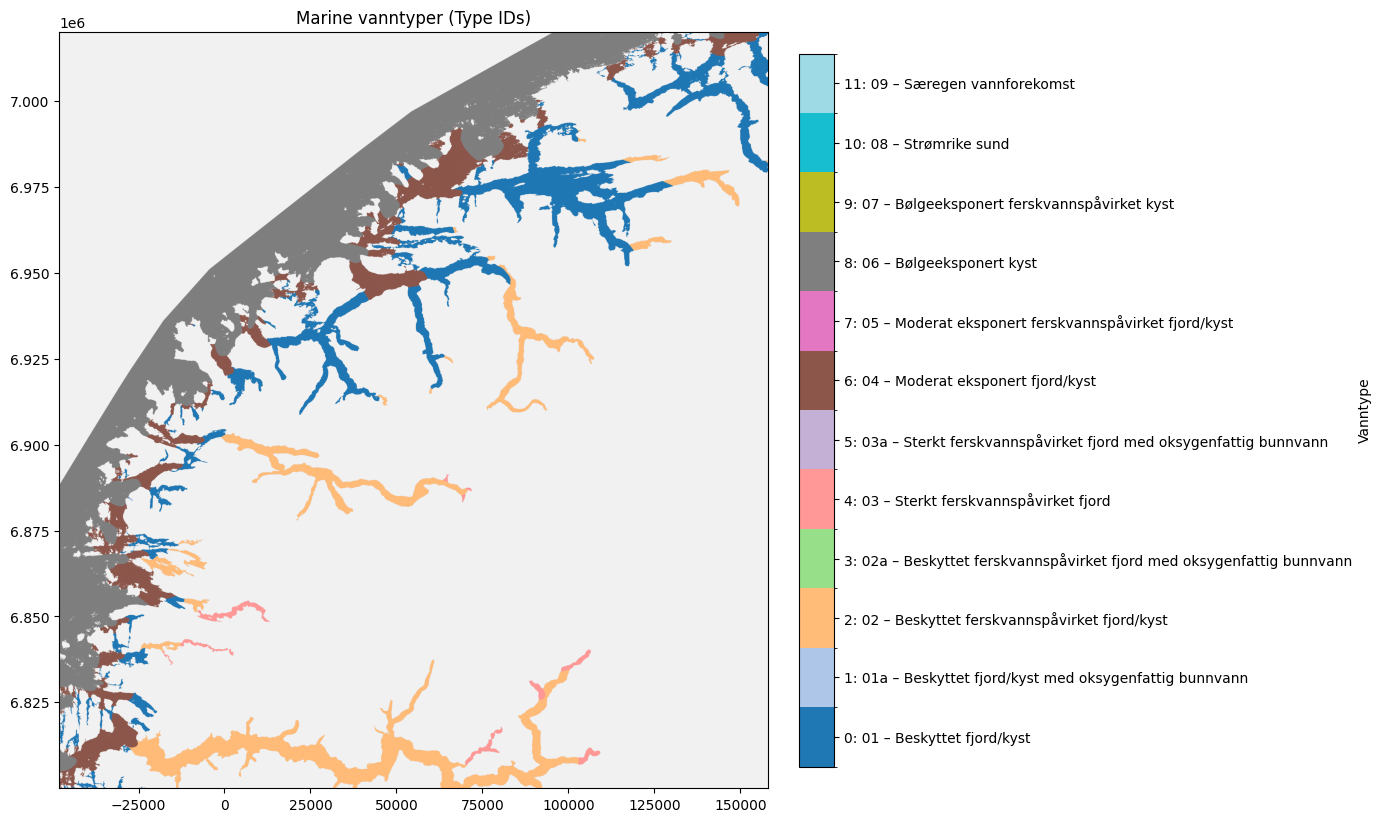

In [6]:
utils.plot_vanntyper(marine_type_raster, transform, id_type_map)


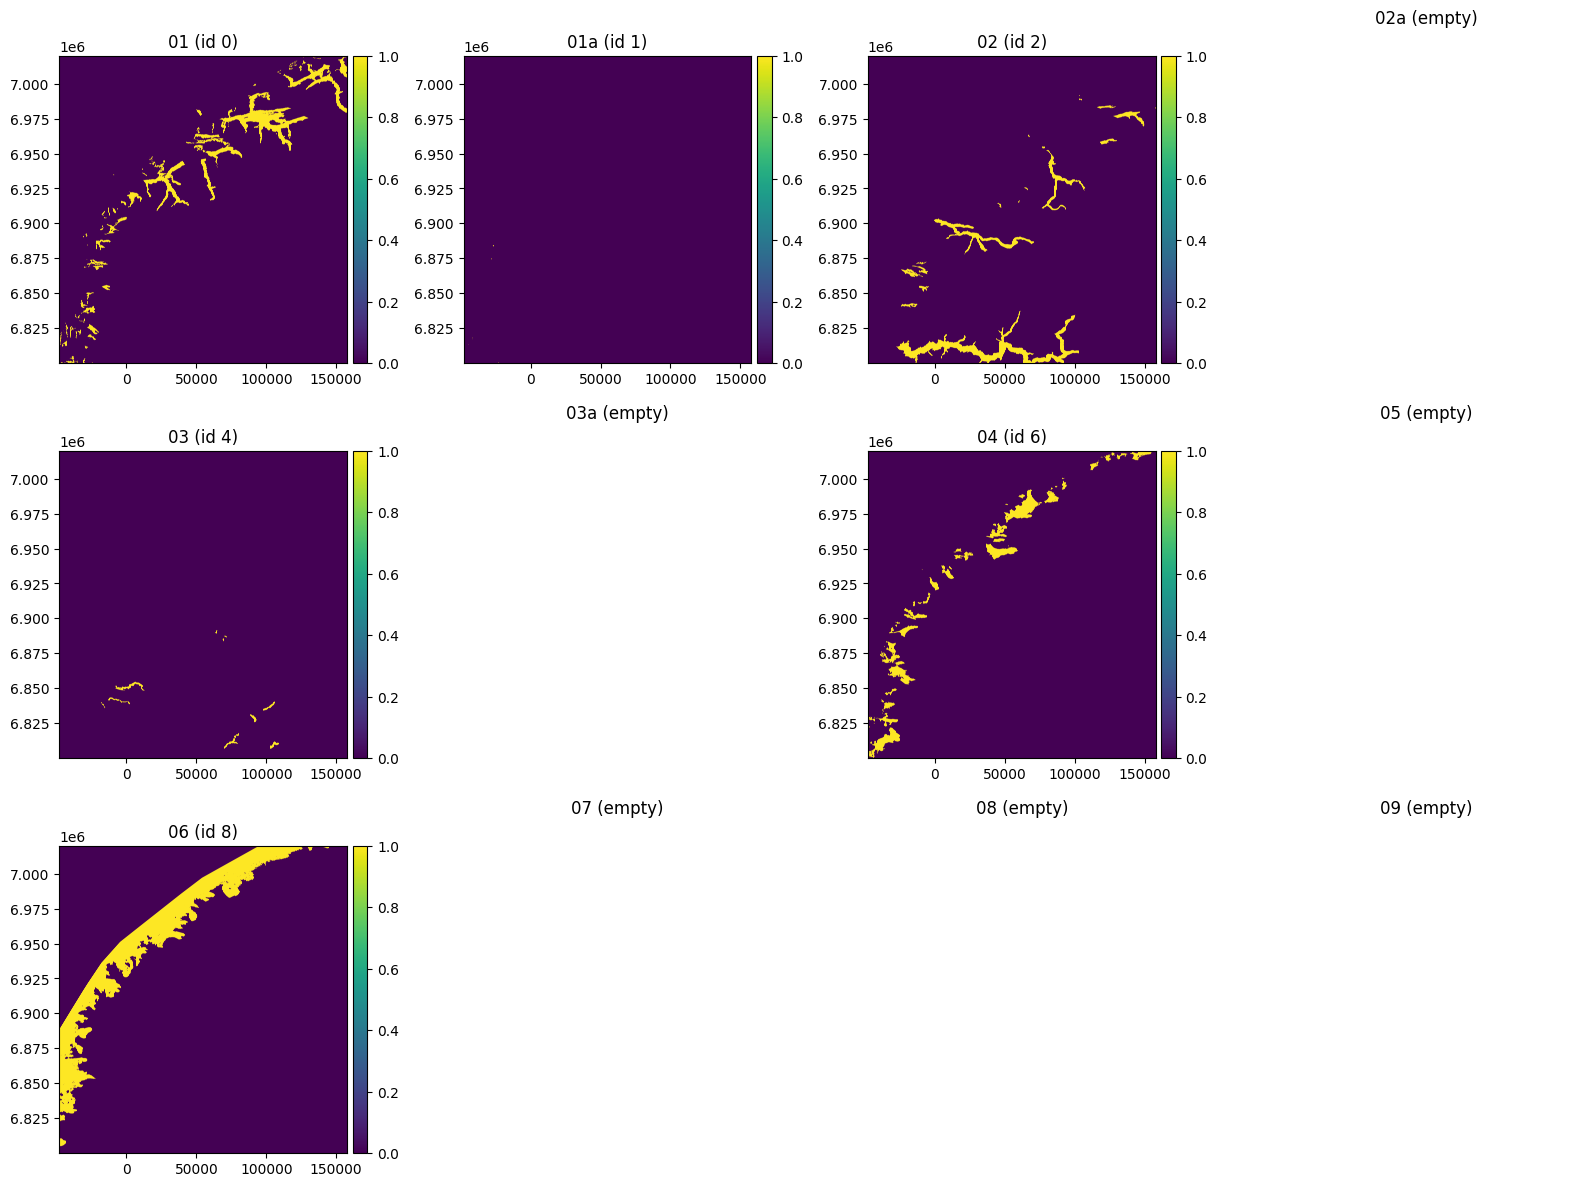

In [22]:

# Plot the first one-hot marine type layer using geoutils
# Check if all values in one_hot_types are zero
utils.plot_one_hot_vanntyper(one_hot_types, id_type_map, transform, dem.crs)



## Dataset for labels

Using NGU bunnsedimenter detaljert

In [9]:
gdf_bunn_full = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/soft_hard_bottom_from_BunnsedimentKornstorDetalj.geo.parquet")
gdf_bunn_full = gdf_bunn_full.to_crs(dem.crs)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

['fastbunn', 'løsbunn', 'uspesifisert']

In [ ]:
# Rasterize gdf_bunn_full: løsbunn -> 0, fastbunn -> 1, others -> 255 (uint8), using DEM grid
# Requires gdf_bunn_full already in dem.crs (done in a previous cell)

# Map BunnType to label values
mapping_values = {"løsbunn": 0, "fastbunn": 1}

# Prepare shapes as (geometry, value)
shapes = [
    (geom, mapping_values[btype])
    for geom, btype in zip(gdf_bunn_full.geometry, gdf_bunn_full["BunnType"])
    if btype in mapping_values
]

# Rasterize to uint8 with fill=255 for "other/none"
bunn_raster = rio.features.rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    fill=255,
    dtype=np.uint8,
    all_touched=True
)

In [ ]:

features = np.concatenate(
    [np.stack([slope, aspect, curvature, depth], axis=-1), one_hot_types.astype(np.float16)],
    axis=-1
)
features.shape

In [19]:
#Prepare a binary classification dataset where featurbes come from the masked terrain attributes, and labels are bunn_mask_12. Train/validation split and #RandomForest setup:

# Build feature matrix from masked terrain attributes
depth = np.ma.filled(dem.data, np.nan).astype(np.float16)
features = np.stack([slope, aspect, curvature, depth], axis=-1)

# Valid pixels: finite features and BunnType in {0,1}
valid_attrs = (~np.isnan(slope)) & (~np.isnan(aspect)) & (~np.isnan(curvature))
valid_bunn = np.isin(bunn_raster, (0, 1))
valid = valid_attrs & valid_bunn

X = features[valid]
y = bunn_raster[valid].astype(np.uint8)  # labels: {0,1}

# Compute class weights from actual label distribution
classes = np.array([0, 1], dtype=np.uint8)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
w0, w1 = float(class_weights[0]), float(class_weights[1])

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RandomForest model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight={0: w0, 1: w1}
)

rf.fit(X_train, y_train)

print("Train accuracy:", rf.score(X_train, y_train))
print("Validation accuracy:", rf.score(X_val, y_val))


Train accuracy: 0.9734416574525361
Validation accuracy: 0.8114005276514833


## Predict for AOI

In [20]:

gdf_bunn_moere = gpd.read_file("https://storage.googleapis.com/niva-geodata/MarintNaturKart/bunn_in_kommuner_sea.geojson")


In [21]:
# Use geoutils to clip the DEM by the gdf_bunn_moere polygons

# Ensure polygons are in DEM CRS
gdf_clip = gdf_bunn_moere.to_crs(dem.crs)

# Wrap inputs with geoutils
vec_clip = gu.Vector(gdf_clip)


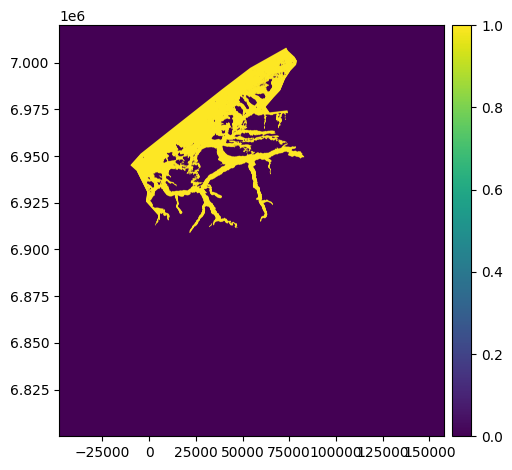

In [22]:
vect_rasterized = vec_clip.create_mask(dem)
vect_rasterized.plot(ax="new")

In [23]:
arr2d = np.array(dem.data, dtype=np.float16)
arr2d[~vect_rasterized.data] = np.nan
dem_clipped = xdem.DEM.from_array(arr2d, transform=dem.transform, crs=dem.crs)

/home/kim/work/marint-naturkart-nivaR/.venv/lib64/python3.13/site-packages/geoutils/raster/raster.py:1748: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/home/kim/work/marint-naturkart-nivaR/.venv/lib64/python3.13/site-packages/numpy/ma/core.py:509: RuntimeWarning: overflow encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/home/kim/work/marint-naturkart-nivaR/.venv/lib64/python3.13/site-packages/geoutils/raster/raster.py:1783: RuntimeWarning: overflow encountered in cast
  if np.count_nonzero(np.logical_and(~self._data.mask, self._data.data == self.nodata)) > 0:


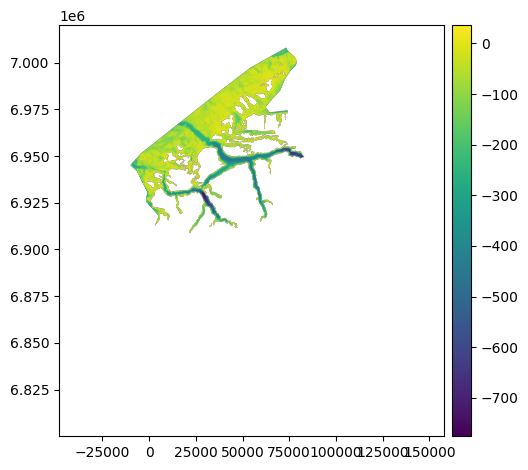

In [24]:
dem_clipped.plot()

In [19]:
cropped_attributes = xdem.terrain.get_terrain_attribute(
    dem_clipped.data,
    resolution=dem_clipped.res,
    attribute=["slope", "aspect", "curvature"],
)

In [20]:
cropped_slope, cropped_aspect, cropped_curvature = cropped_attributes[0], cropped_attributes[1], cropped_attributes[2]

In [23]:
depth_clipped = np.ma.filled(dem_clipped.data, np.nan).astype(np.float16)
features = np.stack([cropped_slope, cropped_aspect, cropped_curvature, depth_clipped], axis=-1)
valid_attrs = (~np.isnan(cropped_slope)) & (~np.isnan(cropped_aspect)) & (~np.isnan(cropped_curvature))

cropped_X = features[valid_attrs]

In [24]:
Y_pred = rf.predict(cropped_X)

In [25]:
pred_map = np.full(dem_clipped.data.shape[-2:], np.nan, dtype=np.float16)
pred_map[valid_attrs] = Y_pred.astype(np.float16)

In [26]:

pred_raster = gu.Raster.from_array(pred_map, transform=dem_clipped.transform, crs=dem_clipped.crs)


/opt/conda/lib/python3.13/site-packages/geoutils/raster/raster.py:1748: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/numpy/ma/core.py:489: RuntimeWarning: overflow encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/opt/conda/lib/python3.13/site-packages/geoutils/raster/raster.py:1783: RuntimeWarning: overflow encountered in cast
  if np.count_nonzero(np.logical_and(~self._data.mask, self._data.data == self.nodata)) > 0:


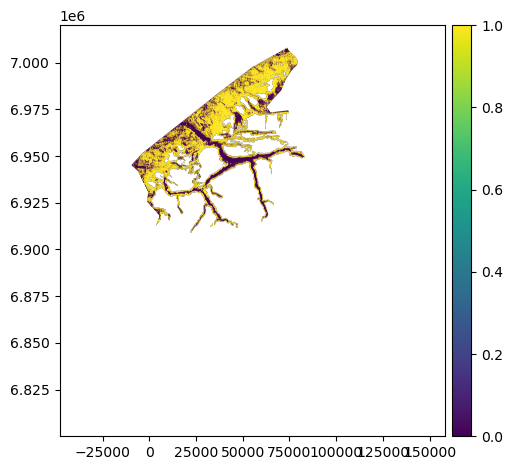

In [27]:
pred_raster.plot()

In [28]:
pred_vec = pred_raster.polygonize()

/opt/conda/lib/python3.13/site-packages/numpy/ma/core.py:489: RuntimeWarning: invalid value encountered in cast
  fill_value = np.asarray(fill_value, dtype=ndtype)
/opt/conda/lib/python3.13/site-packages/geoutils/interface/raster_vector.py:91: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


In [29]:
# Map raster_value (0/1) to BunnType using existing mapping_values
reverse_map = {v: k for k, v in mapping_values.items()}
pred_vec["BunnType"] = pred_vec["raster_value"].map(reverse_map)

pred_vec["BunnType"]

0         fastbunn
1         fastbunn
2         fastbunn
3         fastbunn
4          løsbunn
            ...   
175914     løsbunn
175915     løsbunn
175916     løsbunn
175917     løsbunn
175918    fastbunn
Name: BunnType, Length: 175919, dtype: object

In [30]:
gdf_final = pred_vec.ds.dissolve(by="BunnType", as_index=False, method="coverage")

In [31]:
gdf_final = gdf_final.to_crs("EPSG:25833")

In [ ]:
fname = utils.to_filename("nisjedata-substrat-randomforest", "moere-og-romsdal", "latest", gdf_final.crs.to_epsg())
gdf_final = gdf_final.drop(columns=["depth_range", "class"], errors="ignore")
gdf_final.to_file(f"{fname}.geojson", driver="GeoJSON")

In [33]:
gdf_final.to_file(f"{fname}.gpkg", layer="soft_hard_bottom", driver="GPKG")